<a href="https://colab.research.google.com/github/ManishKudtarkar/Python-Notebook/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1: Load the Dataset**

1. Import necessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load the dataset

In [4]:
train_df = pd.read_csv('/content/train.csv')
test_df = pd.read_csv('/content/test.csv')
gender_submission_df = pd.read_csv('/content/gender_submission.csv')

3. Display the first five rows of the dataset

In [5]:
print("Train DataFrame:")
display(train_df.head())

print("\nTest DataFrame:")
display(test_df.head())

print("\nGender Submission DataFrame:")
display(gender_submission_df.head())

Train DataFrame:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Test DataFrame:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S



Gender Submission DataFrame:


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


# **Task 2: Handle Missing Values**


### 1. Identify missing values in each column

In [6]:
print("Missing values in train_df:")
print(train_df.isnull().sum())

print("\nMissing values in test_df:")
print(test_df.isnull().sum())

Missing values in train_df:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing values in test_df:
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


### 2. Drop columns with too many missing values (threshold: more than 50% missing)

In [7]:
train_missing_percentage = train_df.isnull().sum() / len(train_df) * 100
train_cols_to_drop = train_missing_percentage[train_missing_percentage > 50].index
train_df = train_df.drop(columns=train_cols_to_drop)

test_missing_percentage = test_df.isnull().sum() / len(test_df) * 100
test_cols_to_drop = test_missing_percentage[test_missing_percentage > 50].index
test_df = test_df.drop(columns=test_cols_to_drop)

print("Columns dropped from train_df:", train_cols_to_drop)
print("Columns dropped from test_df:", test_cols_to_drop)

print("\nTrain DataFrame after dropping columns:")
display(train_df.head())

print("\nTest DataFrame after dropping columns:")
display(test_df.head())

Columns dropped from train_df: Index(['Cabin'], dtype='object')
Columns dropped from test_df: Index(['Cabin'], dtype='object')

Train DataFrame after dropping columns:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S



Test DataFrame after dropping columns:


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,S


### 3. Fill missing numerical values with the median of the respective column

In [8]:
train_age_median = train_df['Age'].median()
train_df['Age'].fillna(train_age_median, inplace=True)

test_age_median = test_df['Age'].median()
test_df['Age'].fillna(test_age_median, inplace=True)

test_fare_median = test_df['Fare'].median()
test_df['Fare'].fillna(test_fare_median, inplace=True)

print("Missing values in train_df after filling:")
print(train_df[['Age', 'Embarked']].isnull().sum())

print("\nMissing values in test_df after filling:")
print(test_df[['Age', 'Fare']].isnull().sum())

Missing values in train_df after filling:
Age         0
Embarked    2
dtype: int64

Missing values in test_df after filling:
Age     0
Fare    0
dtype: int64


/tmp/ipython-input-1964657350.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_age_median, inplace=True)
/tmp/ipython-input-1964657350.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

### 4. Fill missing categorical values with the most frequent value (mode)


In [9]:
train_embarked_mode = train_df['Embarked'].mode()[0]
train_df['Embarked'].fillna(train_embarked_mode, inplace=True)

print("Missing values in train_df after filling Embarked:")
print(train_df['Embarked'].isnull().sum())

Missing values in train_df after filling Embarked:
0


/tmp/ipython-input-3222339435.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_embarked_mode, inplace=True)


###cleaned dataset without missing values.

In [10]:
print("Missing values in train_df after handling:")
print(train_df.isnull().sum())

print("\nMissing values in test_df after handling:")
print(test_df.isnull().sum())

Missing values in train_df after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Missing values in test_df after handling:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#**Task 3: Handle Duplicate Data**


1. Check for duplicate rows


In [12]:
# Check for duplicate rows
train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print(f"Number of duplicate rows in train_df: {train_duplicates}")
print(f"Number of duplicate rows in test_df: {test_duplicates}")

Number of duplicate rows in train_df: 0
Number of duplicate rows in test_df: 0


2. Remove duplicate rows


In [13]:
# Remove duplicate rows
train_df_cleaned = train_df.drop_duplicates()
test_df_cleaned = test_df.drop_duplicates()

print(f"\nNumber of rows in train_df after removing duplicates: {len(train_df_cleaned)}")
print(f"Number of rows in test_df after removing duplicates: {len(test_df_cleaned)}")


Number of rows in train_df after removing duplicates: 891
Number of rows in test_df after removing duplicates: 418


We have now handled the duplicate data by checking for and removing duplicate rows from both the training and testing datasets.

#**Task 4: Convert Categorical Features to Numeric**

To identify categorical and boolean columns.



In [19]:
print("Data types of train_df_cleaned:")
print(train_df_cleaned.dtypes)

print("\nData types of test_df_cleaned:")
print(test_df_cleaned.dtypes)

Data types of train_df_cleaned:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object

Data types of test_df_cleaned:
PassengerId      int64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object


1. Convert categorical columns (sex, embark_town, class, etc.) using one-hot encoding

In [29]:
#train_df_cleaned = pd.get_dummies(train_df_cleaned, columns=['Sex', 'Embarked'], dummy_na=False)
# test_df_cleaned = pd.get_dummies(test_df_cleaned, columns=['Sex', 'Embarked'], dummy_na=False)

print("Train DataFrame after one-hot encoding:")
display(train_df_cleaned.head())

print("\nTest DataFrame after one-hot encoding:")
display(test_df_cleaned.head())

Train DataFrame after one-hot encoding:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,0,0,1



Test DataFrame after one-hot encoding:


,PassengerId,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",34.5,0,0,330911,7.8292,0,1,0,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",47.0,1,0,363272,7.0000,1,0,0,0,1
2,894,2,"Myles, Mr. Thomas Francis",62.0,0,0,240276,9.6875,0,1,0,1,0
3,895,3,"Wirz, Mr. Albert",27.0,0,0,315154,8.6625,0,1,0,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,1,1,3101298,12.2875,1,0,0,0,1



2. Convert Boolean columns (alone, who) to numeric (0 and 1)

In [24]:
for col in train_df_cleaned.columns:
    if train_df_cleaned[col].dtype == 'bool':
        train_df_cleaned[col] = train_df_cleaned[col].astype(int)

for col in test_df_cleaned.columns:
    if test_df_cleaned[col].dtype == 'bool':
        test_df_cleaned[col] = test_df_cleaned[col].astype(int)

print("Data types of train_df_cleaned after boolean conversion:")
print(train_df_cleaned.dtypes)

print("\nData types of test_df_cleaned after boolean conversion:")
print(test_df_cleaned.dtypes)

Data types of train_df_cleaned after boolean conversion:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object

Data types of test_df_cleaned after boolean conversion:
PassengerId      int64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object


Combine dataframes



In [21]:
combined_df = pd.concat([train_df_cleaned, test_df_cleaned], ignore_index=True)
combined_df.reset_index(drop=True, inplace=True)
print("Combined DataFrame:")
display(combined_df.head())
print("\nShape of Combined DataFrame:", combined_df.shape)

Combined DataFrame:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,1,0,0,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,1,0,0
2,3,1.0,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0,0,0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,0,0,1
4,5,0.0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,0,0,1



Shape of Combined DataFrame: (1309, 14)


The dataset with all categorical columns transformed into numeric values

In [22]:
display(combined_df.head())
print(combined_df.dtypes)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,1,0,0,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,1,0,0
2,3,1.0,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,0,0,0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,0,0,1
4,5,0.0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,0,0,1


PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object


#**Task 5: Feature Scaling**


Identify the numerical columns in the `combined_df` that need to be scaled.


In [30]:
print(combined_df.dtypes)

numerical_cols = combined_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cols_to_scale = [col for col in numerical_cols if col not in ['PassengerId', 'Survived']]

print("\nNumerical columns to scale:")
print(cols_to_scale)

PassengerId      int64
Survived       float64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Sex_female       int64
Sex_male         int64
Embarked_C       int64
Embarked_Q       int64
Embarked_S       int64
dtype: object

Numerical columns to scale:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


1. Normalize numerical features (age, fare, etc.) using Min-Max Scaling

In [31]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
combined_df_minmax = combined_df.copy()
combined_df_minmax[cols_to_scale] = scaler.fit_transform(combined_df_minmax[cols_to_scale])

print("Combined DataFrame after Min-Max Scaling:")
display(combined_df_minmax.head())
print("\nDescriptive statistics of scaled columns:")
display(combined_df_minmax[cols_to_scale].describe())

Combined DataFrame after Min-Max Scaling:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,1.0,"Braund, Mr. Owen Harris",0.273456,0.125,0.0,A/5 21171,0.014151,0.0,1.0,0.0,0.0,1.0
1,2,1.0,0.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.473882,0.125,0.0,PC 17599,0.139136,1.0,0.0,1.0,0.0,0.0
2,3,1.0,1.0,"Heikkinen, Miss. Laina",0.323563,0.000,0.0,STON/O2. 3101282,0.015469,1.0,0.0,0.0,0.0,1.0
3,4,1.0,0.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.436302,0.125,0.0,113803,0.103644,1.0,0.0,0.0,0.0,1.0
4,5,0.0,1.0,"Allen, Mr. William Henry",0.436302,0.000,0.0,373450,0.015713,0.0,1.0,0.0,0.0,1.0



Descriptive statistics of scaled columns:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.647441,0.366623,0.062357,0.042781,0.064960,0.355997,0.644003,0.206264,0.093965,0.699771
std,0.418918,0.161785,0.130207,0.096173,0.100993,0.478997,0.478997,0.404777,0.291891,0.458533
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.273456,0.000000,0.000000,0.015412,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.348616,0.000000,0.000000,0.028213,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,0.436302,0.125000,0.000000,0.061045,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


2. Standardize numerical features using StandardScaler and compare results Expected Output: A scaled dataset where all numerical features are normalized/standardized.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
combined_df_standard = combined_df.copy()
combined_df_standard[cols_to_scale] = scaler.fit_transform(combined_df_standard[cols_to_scale])

print("Combined DataFrame after Standardization:")
display(combined_df_standard.head())

print("\nDescriptive statistics of scaled columns:")
display(combined_df_standard[cols_to_scale].describe())

Combined DataFrame after Standardization:


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,0.841916,"Braund, Mr. Owen Harris",-0.576088,0.481288,-0.445,A/5 21171,-0.503291,-0.743497,0.743497,-0.50977,-0.32204,0.655011
1,2,1.0,-1.546098,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663229,0.481288,-0.445,PC 17599,0.734744,1.344995,-1.344995,1.96167,-0.32204,-1.526692
2,3,1.0,0.841916,"Heikkinen, Miss. Laina",-0.266258,-0.479087,-0.445,STON/O2. 3101282,-0.490240,1.344995,-1.344995,-0.50977,-0.32204,0.655011
3,4,1.0,-1.546098,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.430857,0.481288,-0.445,113803,0.383183,1.344995,-1.344995,-0.50977,-0.32204,0.655011
4,5,0.0,0.841916,"Allen, Mr. William Henry",0.430857,-0.479087,-0.445,373450,-0.487824,-0.743497,0.743497,-0.50977,-0.32204,0.655011



Descriptive statistics of scaled columns:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03
mean,-2.062691e-16,4.749617e-18,-1.628440e-17,1.730218e-17,-2.442660e-17,-1.275611e-16,1.275611e-16,-1.004205e-16,-5.835244e-17,-5.699541e-17
std,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00
min,-1.546098e+00,-2.266980e+00,-4.790868e-01,-4.449995e-01,-6.434642e-01,-7.434969e-01,-1.344995e+00,-5.097698e-01,-3.220403e-01,-1.526692e+00
25%,-3.520907e-01,-5.760875e-01,-4.790868e-01,-4.449995e-01,-4.908050e-01,-7.434969e-01,-1.344995e+00,-5.097698e-01,-3.220403e-01,-1.526692e+00
50%,8.419164e-01,-1.113438e-01,-4.790868e-01,-4.449995e-01,-3.640034e-01,-7.434969e-01,7.434969e-01,-5.097698e-01,-3.220403e-01,6.550109e-01
75%,8.419164e-01,4.308572e-01,4.812878e-01,-4.449995e-01,-3.878613e-02,1.344995e+00,7.434969e-01,-5.097698e-01,-3.220403e-01,6.550109e-01
max,8.419164e-01,3.916435e+00,7.203909e+00,9.956864e+00,9.262028e+00,1.344995e+00,7.434969e-01,1.961670e+00,3.105202e+00,6.550109e-01



Display the descriptive statistics for the scaled numerical columns


In [33]:
print("Descriptive statistics after Min-Max Scaling:")
display(combined_df_minmax[cols_to_scale].describe())

print("\nDescriptive statistics after Standardization:")
display(combined_df_standard[cols_to_scale].describe())

Descriptive statistics after Min-Max Scaling:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,0.647441,0.366623,0.062357,0.042781,0.064960,0.355997,0.644003,0.206264,0.093965,0.699771
std,0.418918,0.161785,0.130207,0.096173,0.100993,0.478997,0.478997,0.404777,0.291891,0.458533
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.500000,0.273456,0.000000,0.000000,0.015412,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.348616,0.000000,0.000000,0.028213,0.000000,1.000000,0.000000,0.000000,1.000000
75%,1.000000,0.436302,0.125000,0.000000,0.061045,1.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



Descriptive statistics after Standardization:


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03,1.309000e+03
mean,-2.062691e-16,4.749617e-18,-1.628440e-17,1.730218e-17,-2.442660e-17,-1.275611e-16,1.275611e-16,-1.004205e-16,-5.835244e-17,-5.699541e-17
std,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00,1.000382e+00
min,-1.546098e+00,-2.266980e+00,-4.790868e-01,-4.449995e-01,-6.434642e-01,-7.434969e-01,-1.344995e+00,-5.097698e-01,-3.220403e-01,-1.526692e+00
25%,-3.520907e-01,-5.760875e-01,-4.790868e-01,-4.449995e-01,-4.908050e-01,-7.434969e-01,-1.344995e+00,-5.097698e-01,-3.220403e-01,-1.526692e+00
50%,8.419164e-01,-1.113438e-01,-4.790868e-01,-4.449995e-01,-3.640034e-01,-7.434969e-01,7.434969e-01,-5.097698e-01,-3.220403e-01,6.550109e-01
75%,8.419164e-01,4.308572e-01,4.812878e-01,-4.449995e-01,-3.878613e-02,1.344995e+00,7.434969e-01,-5.097698e-01,-3.220403e-01,6.550109e-01
max,8.419164e-01,3.916435e+00,7.203909e+00,9.956864e+00,9.262028e+00,1.344995e+00,7.434969e-01,1.961670e+00,3.105202e+00,6.550109e-01


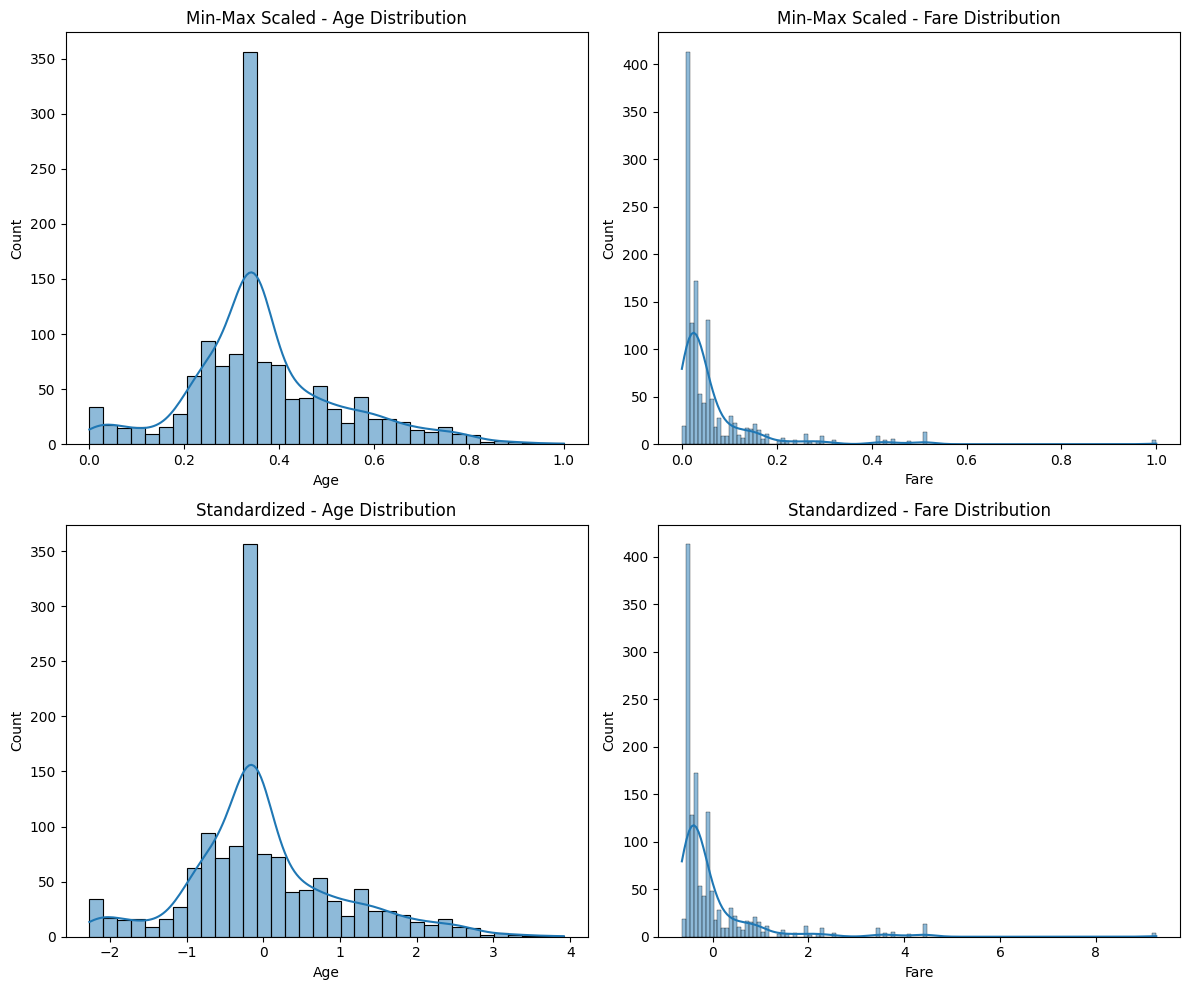

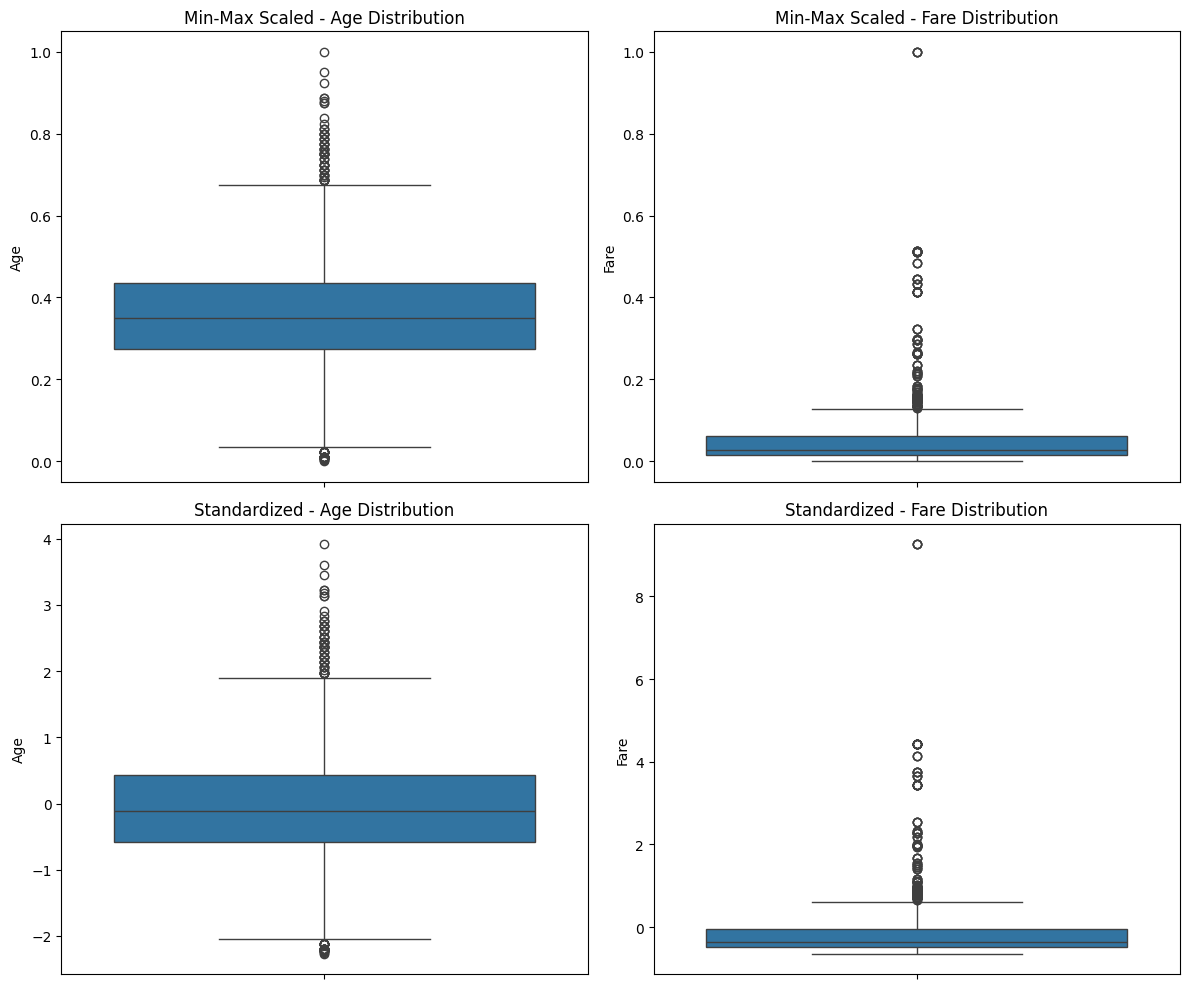

In [34]:
selected_cols = ['Age', 'Fare']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.histplot(combined_df_minmax, x=selected_cols[0], kde=True, ax=axes[0, 0])
axes[0, 0].set_title(f'Min-Max Scaled - {selected_cols[0]} Distribution')
sns.histplot(combined_df_minmax, x=selected_cols[1], kde=True, ax=axes[0, 1])
axes[0, 1].set_title(f'Min-Max Scaled - {selected_cols[1]} Distribution')

sns.histplot(combined_df_standard, x=selected_cols[0], kde=True, ax=axes[1, 0])
axes[1, 0].set_title(f'Standardized - {selected_cols[0]} Distribution')
sns.histplot(combined_df_standard, x=selected_cols[1], kde=True, ax=axes[1, 1])
axes[1, 1].set_title(f'Standardized - {selected_cols[1]} Distribution')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.boxplot(data=combined_df_minmax, y=selected_cols[0], ax=axes[0, 0])
axes[0, 0].set_title(f'Min-Max Scaled - {selected_cols[0]} Distribution')
sns.boxplot(data=combined_df_minmax, y=selected_cols[1], ax=axes[0, 1])
axes[0, 1].set_title(f'Min-Max Scaled - {selected_cols[1]} Distribution')

sns.boxplot(data=combined_df_standard, y=selected_cols[0], ax=axes[1, 0])
axes[1, 0].set_title(f'Standardized - {selected_cols[0]} Distribution')
sns.boxplot(data=combined_df_standard, y=selected_cols[1], ax=axes[1, 1])
axes[1, 1].set_title(f'Standardized - {selected_cols[1]} Distribution')

plt.tight_layout()
plt.show()

#**Task 6: Outlier Detection using IQR Method**



Identify the numerical columns in the combined_df that need outlier detection by excluding the 'PassengerId' and 'Survived' columns.



In [35]:
numerical_cols = combined_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols_for_outliers = [col for col in numerical_cols if col not in ['PassengerId', 'Survived']]

print("Numerical columns for outlier detection:")
print(numerical_cols_for_outliers)

Numerical columns for outlier detection:
['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']


1. Compute the Interquartile Range (IQR) for numerical features (age, fare, etc.).


In [36]:
q1 = combined_df[numerical_cols_for_outliers].quantile(0.25)
q3 = combined_df[numerical_cols_for_outliers].quantile(0.75)
iqr = q3 - q1

print("First Quartile (Q1):\n", q1)
print("\nThird Quartile (Q3):\n", q3)
print("\nInterquartile Range (IQR):\n", iqr)

First Quartile (Q1):
 Pclass         2.0000
Age           22.0000
SibSp          0.0000
Parch          0.0000
Fare           7.8958
Sex_female     0.0000
Sex_male       0.0000
Embarked_C     0.0000
Embarked_Q     0.0000
Embarked_S     0.0000
Name: 0.25, dtype: float64

Third Quartile (Q3):
 Pclass         3.000
Age           35.000
SibSp          1.000
Parch          0.000
Fare          31.275
Sex_female     1.000
Sex_male       1.000
Embarked_C     0.000
Embarked_Q     0.000
Embarked_S     1.000
Name: 0.75, dtype: float64

Interquartile Range (IQR):
 Pclass         1.0000
Age           13.0000
SibSp          1.0000
Parch          0.0000
Fare          23.3792
Sex_female     1.0000
Sex_male       1.0000
Embarked_C     0.0000
Embarked_Q     0.0000
Embarked_S     1.0000
dtype: float64


2. Identify outliers using the 1.5 * IQR rule.

In [37]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("\nLower Bound for Outliers:")
print(lower_bound)

print("\nUpper Bound for Outliers:")
print(upper_bound)


Lower Bound for Outliers:
Pclass         0.500
Age            2.500
SibSp         -1.500
Parch          0.000
Fare         -27.173
Sex_female    -1.500
Sex_male      -1.500
Embarked_C     0.000
Embarked_Q     0.000
Embarked_S    -1.500
dtype: float64

Upper Bound for Outliers:
Pclass         4.5000
Age           54.5000
SibSp          2.5000
Parch          0.0000
Fare          66.3438
Sex_female     2.5000
Sex_male       2.5000
Embarked_C     0.0000
Embarked_Q     0.0000
Embarked_S     2.5000
dtype: float64


3. Remove or replace outliers with appropriate values (e.g., mean/median).


In [38]:
outliers = {}

for col in numerical_cols_for_outliers:
    col_outliers = combined_df[
        (combined_df[col] < lower_bound[col]) | (combined_df[col] > upper_bound[col])
    ]
    if not col_outliers.empty:
        outliers[col] = col_outliers.index.tolist()

print("Identified Outliers (indices by column):")
for col, indices in outliers.items():
    print(f"Column '{col}': {len(indices)} outliers at indices {indices[:10]}...")

Identified Outliers (indices by column):
Column 'Age': 101 outliers at indices [7, 11, 15, 16, 33, 54, 78, 94, 96, 116]...
Column 'SibSp': 57 outliers at indices [7, 16, 24, 27, 50, 59, 63, 68, 71, 85]...
Column 'Parch': 307 outliers at indices [7, 8, 10, 13, 16, 24, 25, 27, 43, 50]...
Column 'Fare': 171 outliers at indices [1, 27, 31, 34, 52, 61, 62, 72, 88, 102]...
Column 'Embarked_C': 270 outliers at indices [1, 9, 19, 26, 30, 31, 34, 36, 39, 42]...
Column 'Embarked_Q': 123 outliers at indices [5, 16, 22, 28, 32, 44, 46, 47, 82, 109]...


In [39]:
for col in ['Age', 'Fare']:
    if col in outliers:
        median_val = combined_df[col].median()
        combined_df.loc[outliers[col], col] = median_val
        print(f"Replaced outliers in '{col}' with median ({median_val}).")

print("\nDescriptive statistics after handling outliers in Age and Fare:")
display(combined_df[['Age', 'Fare']].describe())


Replaced outliers in 'Age' with median (28.0).
Replaced outliers in 'Fare' with median (14.4542).

Descriptive statistics after handling outliers in Age and Fare:


,Age,Fare
count,1309.000000,1309.000000
mean,28.427807,17.501147
std,9.578938,12.942992
min,3.000000,0.000000
25%,24.000000,7.895800
50%,28.000000,14.454200
75%,32.000000,23.450000
max,54.000000,65.000000


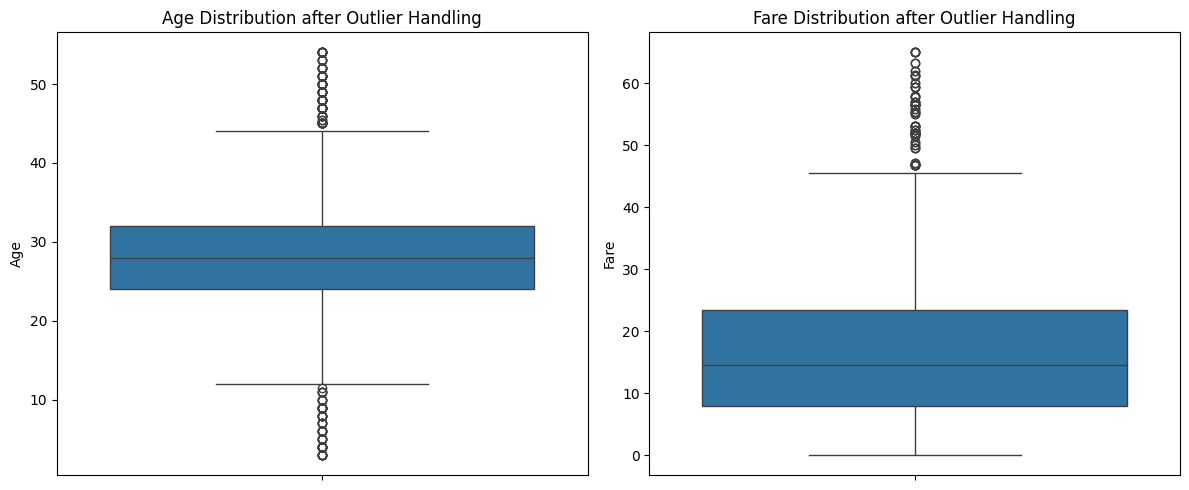

In [40]:
selected_cols = ['Age', 'Fare']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=combined_df, y=selected_cols[0], ax=axes[0])
axes[0].set_title(f'Age Distribution after Outlier Handling')

sns.boxplot(data=combined_df, y=selected_cols[1], ax=axes[1])
axes[1].set_title(f'Fare Distribution after Outlier Handling')

plt.tight_layout()
plt.show()

In [50]:
combined_df.to_csv('cleaned_combined_dataset.csv', index=False)

print("Cleaned dataset saved to 'cleaned_combined_dataset.csv'")

Cleaned dataset saved to 'cleaned_combined_dataset.csv'
